In [19]:
import json
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from umap import UMAP

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from training.train_embedding_space import embed_texts, load_checkpoint_bundle

DATASET_PATH = ROOT / 'data/ToolVerifier/tool_embedding_dataset.jsonl'
CHECKPOINT_PATH = ROOT / 'data/ToolVerifier/output/best.pt'
BENCHMARK_PATH = ROOT / 'data/ToolVerifier/benchmark.json'
DEVICE = 'cuda:3' if torch.cuda.is_available() else 'cpu'
MAX_SAMPLES = 2000
TOP_K_TOOLS = 100
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f'device: {DEVICE}')
print(f'dataset: {DATASET_PATH}')
print(f'checkpoint: {CHECKPOINT_PATH}')


device: cuda:3
dataset: /scratch4/home/akrik/NTILC/data/ToolVerifier/tool_embedding_dataset.jsonl
checkpoint: /scratch4/home/akrik/NTILC/data/ToolVerifier/output/best.pt


In [20]:
def load_jsonl(path):
    with path.open('r', encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]


rows = load_jsonl(DATASET_PATH)
random.shuffle(rows)
rows = rows[:MAX_SAMPLES]

bundle = load_checkpoint_bundle(CHECKPOINT_PATH, device=DEVICE)
tool_names = bundle['tool_names']
tool_to_idx = {tool: idx for idx, tool in enumerate(tool_names)}
texts = [row.get('query', row.get('text', '')) for row in rows]
labels = np.array([tool_to_idx[row['tool']] for row in rows])
tool_counts = Counter(row['tool'] for row in rows)

embeddings = embed_texts(
    model=bundle['model'],
    tokenizer=bundle['tokenizer'],
    texts=texts,
    device=DEVICE,
    max_length=bundle['max_length'],
    batch_size=32,
).numpy()
centroids = bundle['centroids'].detach().cpu().numpy()

print(f'samples: {len(rows)}')
print(f'unique tools in sample: {len(tool_counts)}')
print(f'embedding shape: {embeddings.shape}')
print(tool_counts.most_common(10))


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1669.90it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                    

samples: 2000
unique tools in sample: 124
embedding shape: (2000, 128)
[('get_stock_price', 48), ('get_bank_name', 46), ('airline_seat_selector', 46), ('get_birthday_date', 45), ('real_estate_finder', 36), ('translate_text', 36), ('get_sunset_time', 36), ('movie_recommendation', 36), ('order_pizza', 35), ('restaurant_recommender', 35)]


In [21]:
def normalize_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.clip(norms, 1e-12, None)
    return matrix / norms


normalized_embeddings = normalize_matrix(embeddings)
normalized_centroids = normalize_matrix(centroids)
scores = normalized_embeddings @ normalized_centroids.T
predictions = scores.argmax(axis=1)
retrieval_accuracy = float((predictions == labels).mean())

print(f'retrieval accuracy on sample rows: {retrieval_accuracy:.4f}')
if len(np.unique(labels)) > 1:
    sil = silhouette_score(embeddings, labels, metric='cosine')
    print(f'silhouette score: {sil:.4f}')
else:
    print('Need at least two tools for silhouette score.')


retrieval accuracy on sample rows: 0.9560
silhouette score: 0.4301


/tmp/ipykernel_2062005/2932825446.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


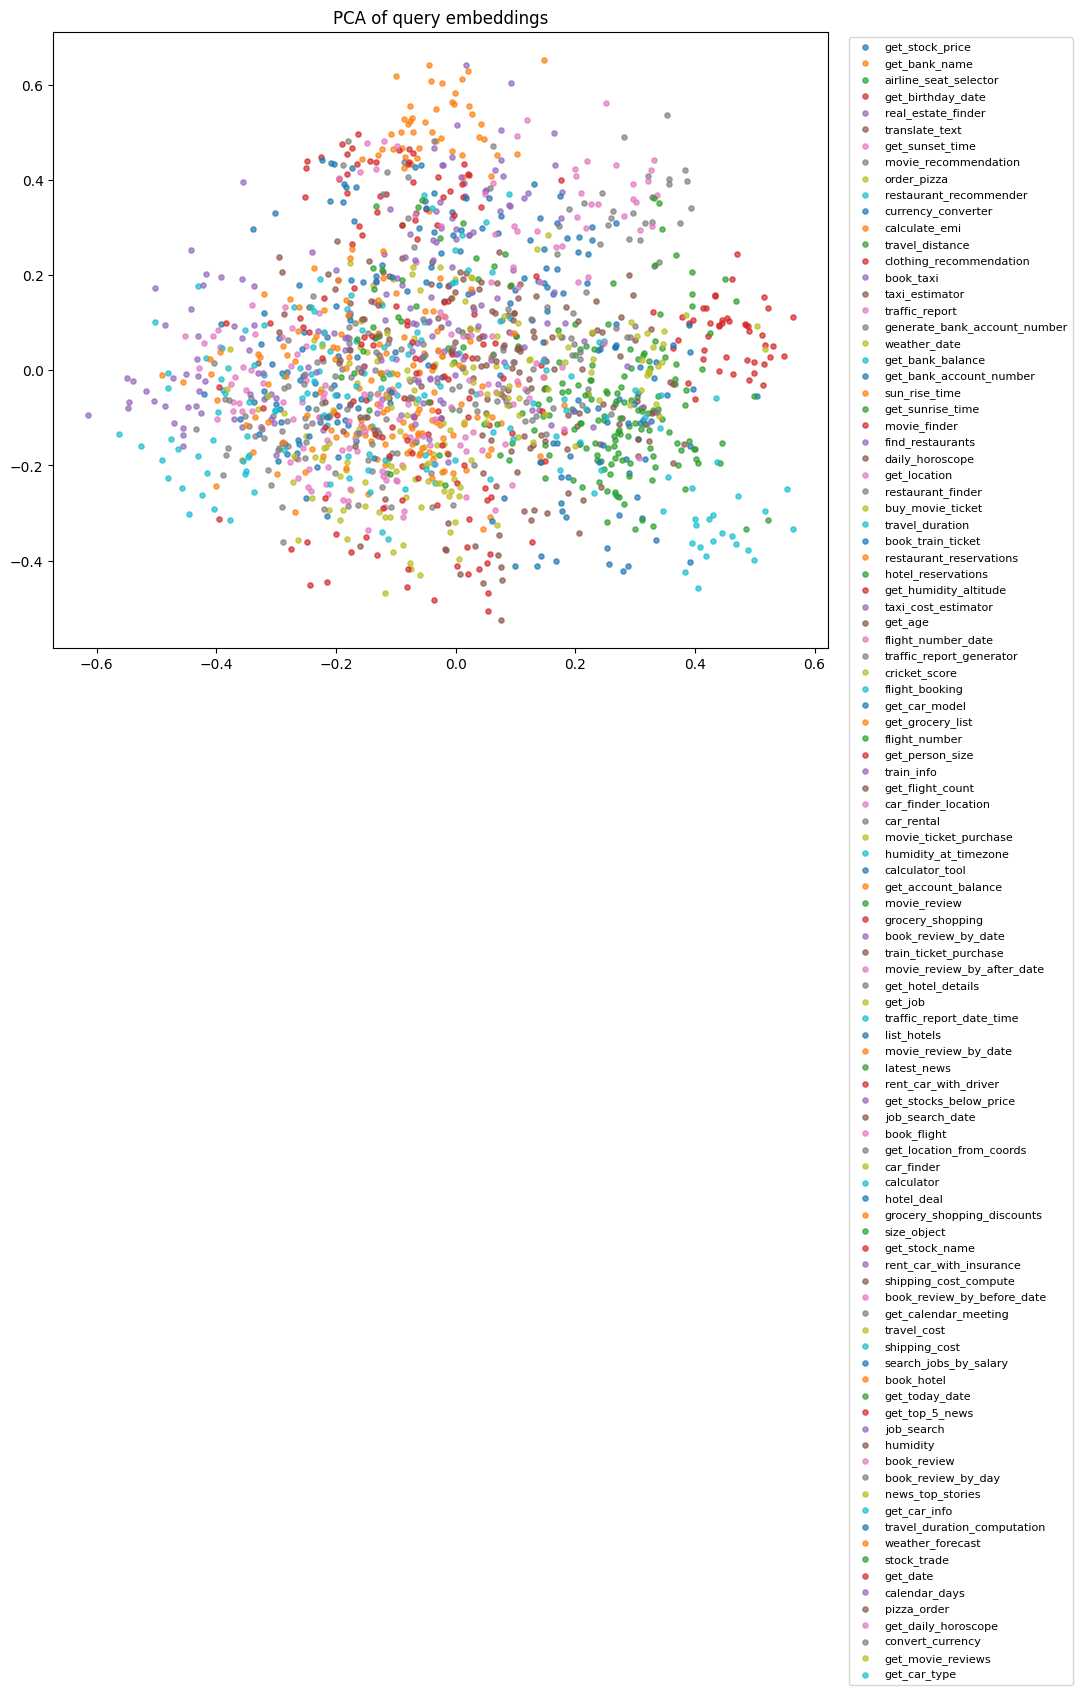

/scratch4/home/akrik/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_2062005/2932825446.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


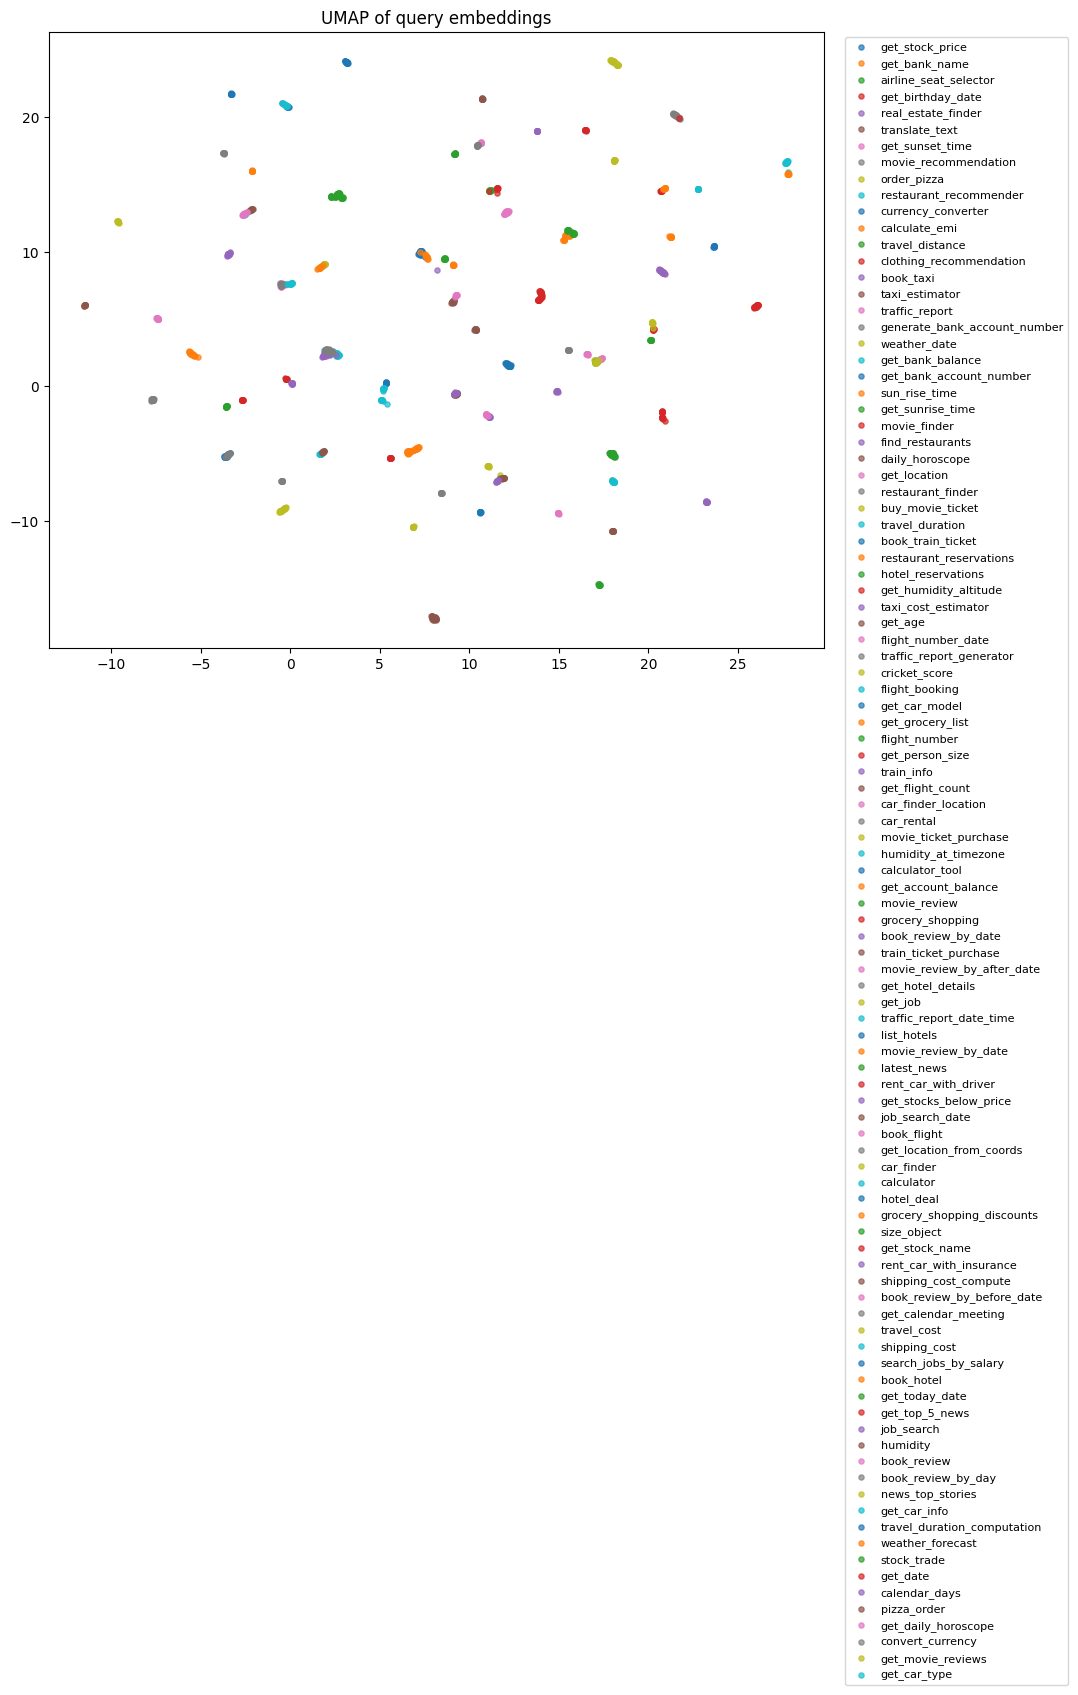

In [22]:
def plot_projection(xy, title):
    top_tools = [tool for tool, _ in tool_counts.most_common(TOP_K_TOOLS)]
    plt.figure(figsize=(10, 8))
    for tool in top_tools:
        idx = [i for i, row in enumerate(rows) if row['tool'] == tool]
        plt.scatter(xy[idx, 0], xy[idx, 1], s=14, alpha=0.7, label=tool)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


plot_projection(
    PCA(n_components=2, random_state=SEED).fit_transform(embeddings),
    'PCA of query embeddings',
)

plot_projection(
    UMAP(n_components=2, random_state=SEED).fit_transform(embeddings),
    'UMAP of query embeddings',
)


In [23]:
examples = []
for idx in random.sample(range(len(rows)), min(12, len(rows))):
    top3_idx = scores[idx].argsort()[::-1][:3]
    examples.append(
        {
            'query': rows[idx]['query'],
            'expected_tool': rows[idx]['tool'],
            'predicted_tool': tool_names[int(predictions[idx])],
            'top3_tools': ', '.join(tool_names[i] for i in top3_idx),
        }
    )

pd.DataFrame(examples)


,query,expected_tool,predicted_tool,top3_tools
0,I need a minivan in Denver for my family trip ...,rent_car_with_insurance,rent_car_with_insurance,"rent_car_with_insurance, rent_car_with_driver,..."
1,What's the info for meeting 5000?,get_calendar_meeting,get_calendar_meeting,"get_calendar_meeting, job_numbers, calculator_..."
2,"I need the monthly payment for a 45,000 euro c...",emi_calculator,emi_calculator,"emi_calculator, calculate_emi, get_news"
3,What's the traffic like in Chicago right now?,traffic_report,traffic_report,"traffic_report, traffic_report_generator, traf..."
4,Which financial institution does Daniel Garcia...,get_bank_name,get_bank_name,"get_bank_name, get_stock_name, get_job"
5,"What does row 10, column C look like?",airline_seat_selector,airline_seat_selector,"airline_seat_selector, get_bank_name, translat..."
6,Can you find me a double room at the Hilton in...,hotel_reservations,hotel_reservations,"hotel_reservations, list_hotels, book_hotel"
7,I need the bank name associated with SWIFT cod...,get_bank_name,get_bank_name,"get_bank_name, get_stock_name, get_bank_balance"
8,How long would a trip from Austin to Dallas take?,travel_duration,travel_duration,"travel_duration, travel_distance_compute, trav..."
9,I need to know the balance of my checking acco...,get_account_balance,get_account_balance,"get_account_balance, get_bank_balance, job_sea..."


In [24]:
# with BENCHMARK_PATH.open('r', encoding='utf-8') as handle:
#     benchmark = json.load(handle)['scenarios']

# benchmark_texts = [item['input'] for item in benchmark]
# benchmark_embeddings = embed_texts(
#     model=bundle['model'],
#     tokenizer=bundle['tokenizer'],
#     texts=benchmark_texts,
#     device=DEVICE,
#     max_length=bundle['max_length'],
#     batch_size=32,
# ).numpy()
# benchmark_scores = normalize_matrix(benchmark_embeddings) @ normalized_centroids.T

# report = []
# for scenario, row_scores in zip(benchmark, benchmark_scores):
#     top5_idx = row_scores.argsort()[::-1][:5]
#     top5_tools = [tool_names[i] for i in top5_idx]
#     expected_tools = scenario.get('expected_tools', [])
#     hit_at_5 = any(tool in top5_tools for tool in expected_tools) if expected_tools else None
#     report.append(
#         {
#             'id': scenario['id'],
#             'title': scenario['title'],
#             'expected_tools': ', '.join(expected_tools),
#             'top5_tools': ', '.join(top5_tools),
#             'hit@5': hit_at_5,
#         }
#     )

# pd.DataFrame(report)
